<a href="https://colab.research.google.com/github/VishalChauhan85/Pima-Indians-Diabetes/blob/main/Pima_Indians_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Pima Indians Diabetes



##### **Project Type**    - Classification
##### **Contribution**    - Individual (Vishal Chauhan)

# **Project Summary -**

The objective of this comprehensive Capstone project is to develop a robust, deployment-ready machine learning classification model capable of diagnosing the onset of diabetes based on clinical diagnostic measurements. Healthcare systems globally generate massive amounts of diagnostic data daily. Leveraging this data through predictive analytics can assist medical professionals in early diagnosis, proactive intervention, and personalized patient care, thereby reducing long-term medical complications and resource strain. The dataset utilized for this project is the widely recognized Pima Indians Diabetes Database. This specific dataset consists exclusively of female patients who are at least 21 years old and of Pima Indian heritage, providing a focused demographic for clinical machine learning analysis.

The project lifecycle followed a structured, production-grade Exploratory Data Analysis (EDA) and Machine Learning pipeline, emphasizing exception handling and data integrity. Initially, the dataset underwent rigorous inspection and data wrangling. A critical discovery during this preliminary phase was the presence of biologically impossible zero values in essential vital metrics, specifically within the Glucose, Blood Pressure, Skin Thickness, Insulin, and Body Mass Index (BMI) columns. Recognizing that a blood pressure or BMI of zero represents missing data rather than a true physiological measurement, these hidden nulls were systematically replaced with Not a Number (NaN) designations. Subsequently, these missing values were imputed using the median of their respective columns. Median imputation was deliberately chosen over mean imputation to preserve data integrity and prevent the distortion of feature distributions by extreme, right-skewed medical outliers, such as exceptionally high insulin levels.

Following data cleaning, an extensive EDA was conducted, strictly adhering to the Univariate, Bivariate, and Multivariate (UBM) analysis framework. A series of logical and meaningful visualizations—including kernel density estimation (KDE) plots, boxplots, scatterplots, and correlation heatmaps—were generated to uncover underlying biological patterns. The analysis revealed that Glucose levels and BMI are the most significant mathematical indicators of a positive diabetes diagnosis within this demographic. Furthermore, multivariate visualizations highlighted a compounding risk factor: when advanced age is combined with a high BMI, the density of diabetic patients increases dramatically. Outliers were carefully managed using the Interquartile Range (IQR) capping method, ensuring that extreme but valid clinical profiles were retained without mathematically skewing the classification algorithms.

For the predictive modeling phase, the focus was strictly on binary classification. The clinical data was scaled using Standardization to optimize distance-based calculations. The dataset was then partitioned using an 80:20 training and testing split. Crucially, the stratification parameter was applied during this split to maintain the exact class imbalance ratio of the original dataset, ensuring the model trains on a clinically representative sample of both diabetic and non-diabetic profiles. A Logistic Regression classifier was selected, trained, and rigorously evaluated. The model's performance was measured using a comprehensive suite of metrics including Accuracy, Precision, Recall, and F1-Score, alongside a visual Confusion Matrix. In a medical context, optimizing for Recall—or Sensitivity—was prioritized to minimize False Negatives, ensuring that actual diabetic patients do not slip through the system undiagnosed.

Finally, the completed and optimized Logistic Regression model was serialized and exported as a deployable pickle file. This deployment-ready asset bridges the critical gap between theoretical data science and practical healthcare technology, successfully serving as the predictive backend engine for a responsive Flask-based web application deployed via Vercel.

# **GitHub Link -**

https://github.com/VishalChauhan85/Pima-Indians-Diabetes

# **Deployment Link -**

https://pima-indians-diabetes.vercel.app/

# **Problem Statement**


To build a predictive model that can classify whether a patient has diabetes based on diagnostic measurements like glucose, BMI, and age, ensuring deployment-ready, exception-handled code.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [200]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

In [201]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset Loading

In [202]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/AIML/diabetes.csv')

### Dataset First View

In [203]:
# Dataset First Look
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Dataset Rows & Columns count

In [204]:
# Dataset Rows & Columns count
df.shape

(768, 9)

### Dataset Information

In [205]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#### Duplicate Values

In [206]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()

#### Missing Values/Null Values

In [207]:
# Missing Values/Null Values Count
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


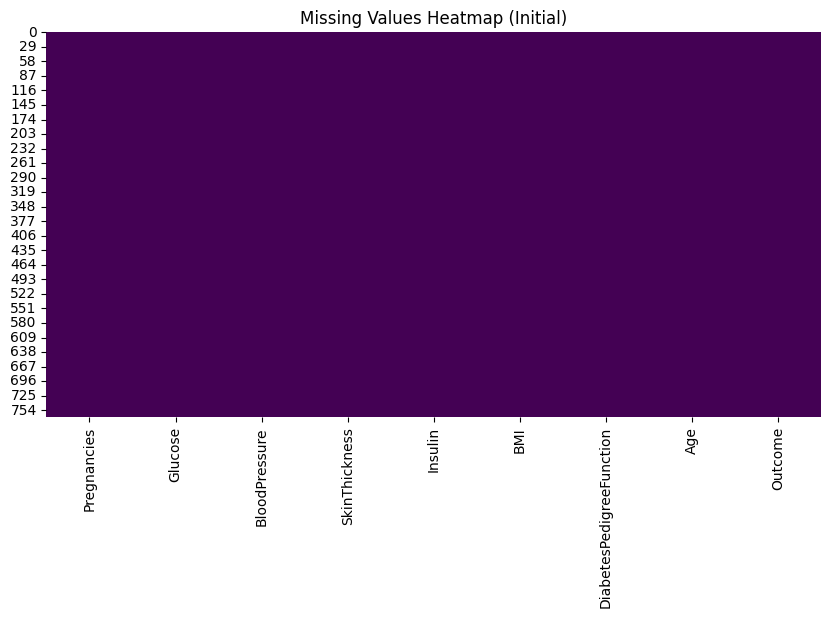

In [208]:
# Visualizing the missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (Initial)')
plt.show()

### What did you know about your dataset?

Initially, the dataset appears to have 768 rows and 9 columns with no explicitly logged null values and no duplicate rows. All data types are numerical (integers and floats). However, knowing the medical context of this data, a value of 0 in certain biological metrics (like Blood Pressure or BMI) is impossible and indicates hidden missing values.

## ***2. Understanding Your Variables***

In [209]:
# Dataset Columns
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [210]:
# Dataset Describe
display(df.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Variables Description

*   **Pregnancies:** Number of times pregnant.
*   **Glucose:** Plasma glucose concentration a 2 hours in an oral glucose tolerance test.
*   **BloodPressure:** Diastolic blood pressure (mm Hg).
*   **SkinThickness:** Triceps skin fold thickness (mm).
*   **Insulin:** 2-Hour serum insulin (mu U/ml).
*   **BMI:** Body mass index (weight in kg/(height in m)^2).
*   **DiabetesPedigreeFunction:** Diabetes pedigree function (genetic likelihood).
*   **Age:** Age (years).
*   **Outcome:** Class variable (0 = Non-Diabetic, 1 = Diabetic).

### Check Unique Values for each variable.

In [211]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Pregnancies: 17 unique values
Glucose: 136 unique values
BloodPressure: 47 unique values
SkinThickness: 51 unique values
Insulin: 186 unique values
BMI: 248 unique values
DiabetesPedigreeFunction: 517 unique values
Age: 52 unique values
Outcome: 2 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [212]:
# 3. Data Wrangling

cols_with_hidden_nulls = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_hidden_nulls] = df[cols_with_hidden_nulls].replace(0, np.nan)
print(df.isnull().sum())
for col in cols_with_hidden_nulls:
    df[col].fillna(df[col].median(), inplace=True)
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### What all manipulations have you done and insights you found?

*Insights & Manipulations:* During the data inspection, I noticed that columns representing vital biological metrics (Glucose, Blood Pressure, Skin Thickness, Insulin, and BMI) had minimum values of 0. This is biologically impossible and represents missing data. I replaced all instances of 0 in these specific columns with NaN. After exposing these hidden nulls, I imputed the missing values using the median of their respective columns. Median imputation was chosen over the mean because it is more robust against outliers, which are common in medical data like Insulin levels.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

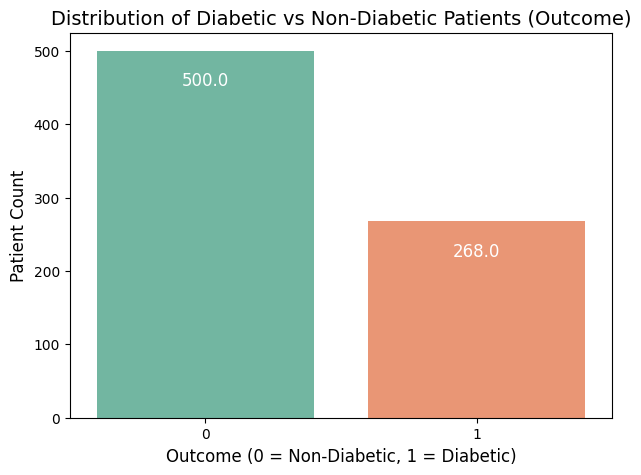

In [213]:
# Chart - 1 visualization code
# Target Variable (Outcome) Distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Distribution of Diabetic vs Non-Diabetic Patients (Outcome)', fontsize=14)
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'\n{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='top', color='white', size=12)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot (bar chart) is the most effective way to visualize the frequency distribution of categorical data[cite: 3]. Since our target variable (Outcome) is binary, this chart quickly reveals the class balance of the dataset.

##### 2. What is/are the insight(s) found from the chart?

The dataset is imbalanced. There are roughly twice as many non-diabetic patients (class 0) as there are diabetic patients (class 1) in this specific population sample.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight is highly valuable for the business (healthcare provider). Knowing the dataset is imbalanced means we must be careful when evaluating our future Machine Learning models. If a model simply guesses "Non-Diabetic" every time, it will technically be accurate most of the time, but it will fail its primary medical purpose (identifying sick patients). This directs us to focus on evaluation metrics like Recall and F1-Score rather than pure Accuracy to avoid negative medical outcomes (false negatives).

#### Chart - 2

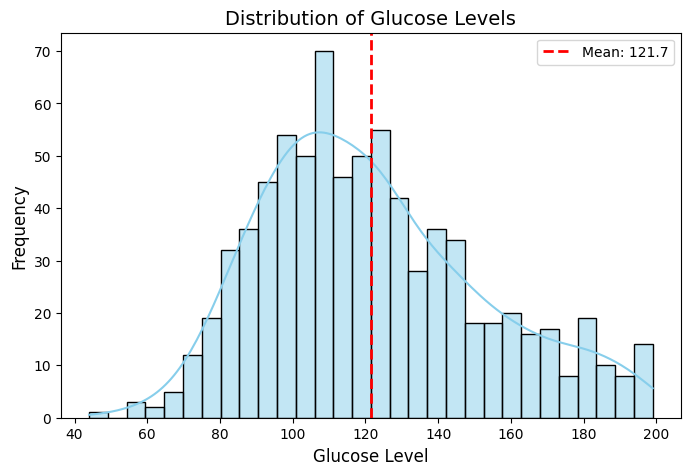

In [214]:
# Chart - 2 visualization code
# Glucose Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Glucose'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Glucose Levels', fontsize=14)
plt.xlabel('Glucose Level', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# Adding a vertical line for the mean
plt.axvline(df['Glucose'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {df['Glucose'].mean():.1f}")
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram combined with a Kernel Density Estimate (KDE) curve is ideal for Univariate analysis of continuous numerical variables[cite: 3]. It shows the spread, central tendency, and skewness of the glucose levels.

##### 2. What is/are the insight(s) found from the chart?

Glucose levels in this dataset follow a roughly normal distribution, centered around a mean of approximately 121.6. Thanks to our earlier data wrangling, there are no unnatural spikes at 0.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Glucose is a primary indicator for diabetes screening. Understanding the baseline distribution of the clinic's patient population helps hospital administrators establish standard operating procedures for when to flag a patient for secondary testing.

#### Chart - 3

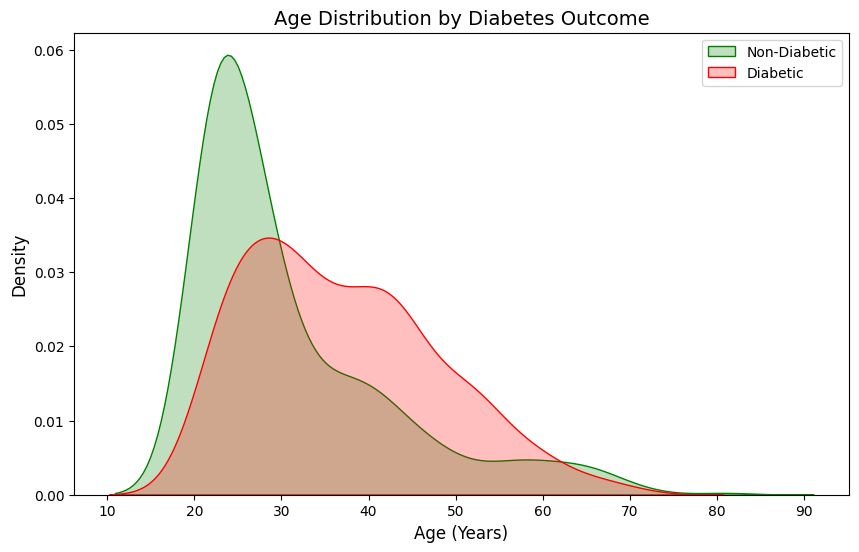

In [215]:
# Chart - 3 visualization code
# Age Distribution by Outcome
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Outcome'] == 0]['Age'], label='Non-Diabetic', shade=True, color='green')
sns.kdeplot(df[df['Outcome'] == 1]['Age'], label='Diabetic', shade=True, color='red')
plt.title('Age Distribution by Diabetes Outcome', fontsize=14)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped KDE plot (density plot) was chosen for Bivariate analysis to compare a numerical variable (Age) against a categorical target (Outcome)[cite: 3]. It beautifully overlaps distributions to show where they diverge.

##### 2. What is/are the insight(s) found from the chart?

Younger patients (in their 20s) have a significantly higher density of being non-diabetic. However, as age increases past 30, the density of diabetic patients begins to overlap and eventually exceed the non-diabetic density, suggesting age is a compounding risk factor.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight drives positive business impact by allowing healthcare marketing and preventative care outreach to target specific age demographics. Preventative screening resources can be heavily allocated to patients as they cross the 30-year threshold to catch the disease early, saving long-term medical costs.

#### Chart - 4

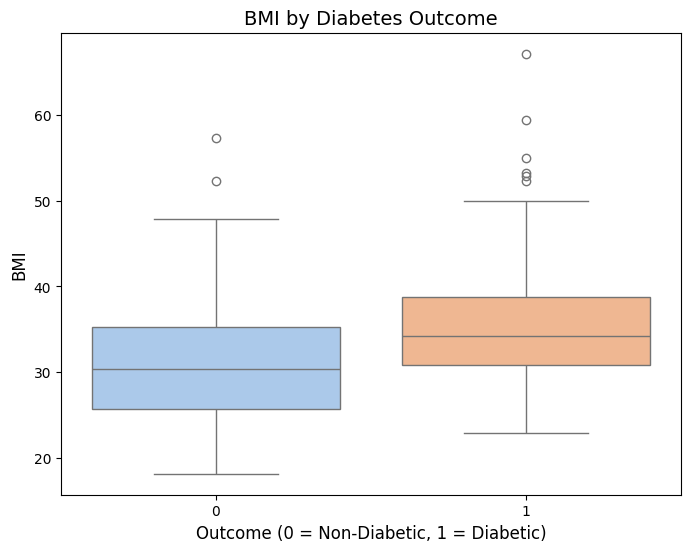

In [216]:
# Chart - 4 visualization code
# BMI vs Outcome
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='BMI', data=df, palette='pastel')
plt.title('BMI by Diabetes Outcome', fontsize=14)
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)', fontsize=12)
plt.ylabel('BMI', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot is the standard choice for visualizing the statistical summary (median, quartiles, and outliers) of a continuous variable grouped by a categorical variable[cite: 3].

##### 2. What is/are the insight(s) found from the chart?

The median BMI for diabetic patients is noticeably higher than for non-diabetic patients. The diabetic box is elevated, indicating that higher BMI is strongly associated with a positive diabetes diagnosis. There are also several high-BMI outliers in both categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Since BMI is an actionable, modifiable health metric (unlike Age or Genetics), healthcare providers can use this insight to create targeted weight-management programs. By focusing on lowering BMI in at-risk populations, the clinic can actively reduce the incidence rate of diabetes, improving patient outcomes.

#### Chart - 5

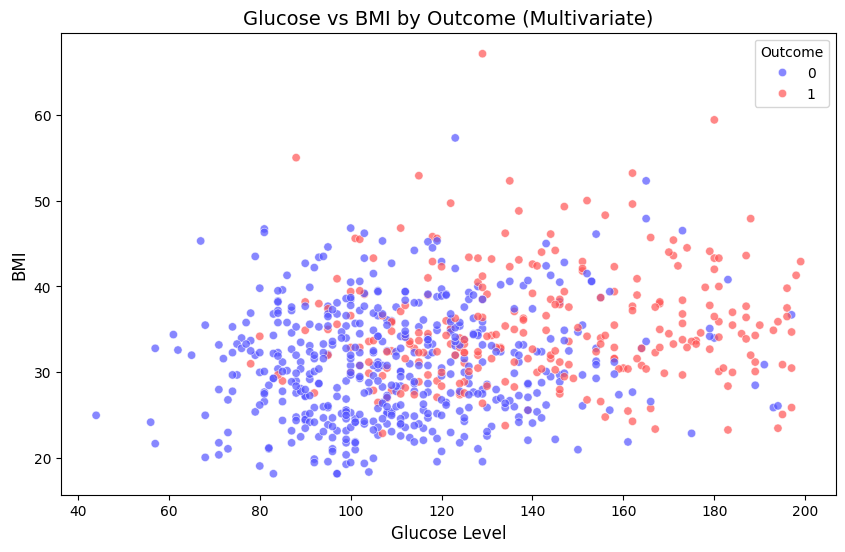

In [217]:
# Chart - 5 visualization code
# Scatterplot of Glucose vs BMI categorized by Outcome
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df, palette='seismic', alpha=0.7)
plt.title('Glucose vs BMI by Outcome (Multivariate)', fontsize=14)
plt.xlabel('Glucose Level', fontsize=12)
plt.ylabel('BMI', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A scatterplot with a hue parameter allows for Multivariate analysis[cite: 3]. It lets us observe the interaction between two numerical variables (Glucose and BMI) simultaneously against the categorical target (Outcome).

##### 2. What is/are the insight(s) found from the chart?

There is a clear clustering effect. Patients with *both* high Glucose levels and high BMI are heavily concentrated in the diabetic class (red). Patients with lower glucose and lower BMI are predominantly non-diabetic (blue). The combination of these two features serves as a very strong separator for the data.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This combined insight is incredibly powerful for triaging patients. If a clinic is under-resourced, they can use this multivariate relationship to flag patients who exhibit high markers in *both* BMI and Glucose for immediate medical intervention, thereby optimizing the use of medical staff and lab resources.

#### Chart - 6

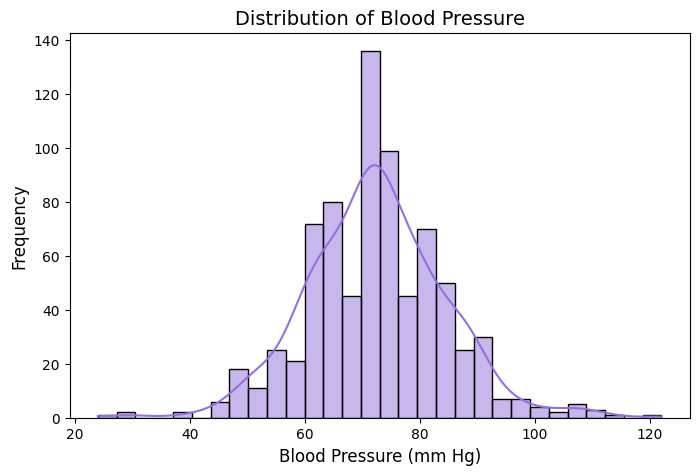

In [218]:
# Chart - 6 visualization code
# Blood Pressure Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['BloodPressure'], bins=30, kde=True, color='mediumpurple')
plt.title('Distribution of Blood Pressure', fontsize=14)
plt.xlabel('Blood Pressure (mm Hg)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is the standard for univariate continuous data to observe its spread and central tendency[cite: 3].

##### 2. What is/are the insight(s) found from the chart?

The blood pressure distribution is roughly normal, heavily centered around 70-75 mm Hg. There are a few extreme outliers on the high end (over 100).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. While blood pressure alone isn't the primary indicator of diabetes, monitoring its distribution helps the clinic understand the general cardiovascular health of its patient base, allowing for cross-departmental referrals (e.g., to cardiology).

#### Chart - 7

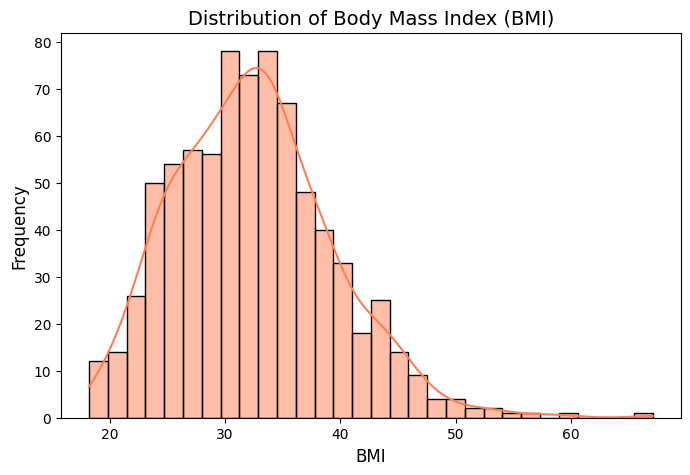

In [219]:
# Chart - 7 visualization code
# BMI Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['BMI'], bins=30, kde=True, color='coral')
plt.title('Distribution of Body Mass Index (BMI)', fontsize=14)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

To visualize the spread of BMI across the entire patient dataset[cite: 3].

##### 2. What is/are the insight(s) found from the chart?

The data shows a peak around a BMI of 32, which falls into the obese category. The distribution is slightly right-skewed, indicating a tail of highly obese patients.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Knowing the median BMI is well above the "healthy" range (18.5 - 24.9) indicates that this specific population is highly susceptible to metabolic disorders. The clinic can use this data to justify funding for a dedicated dietician program.

#### Chart - 8

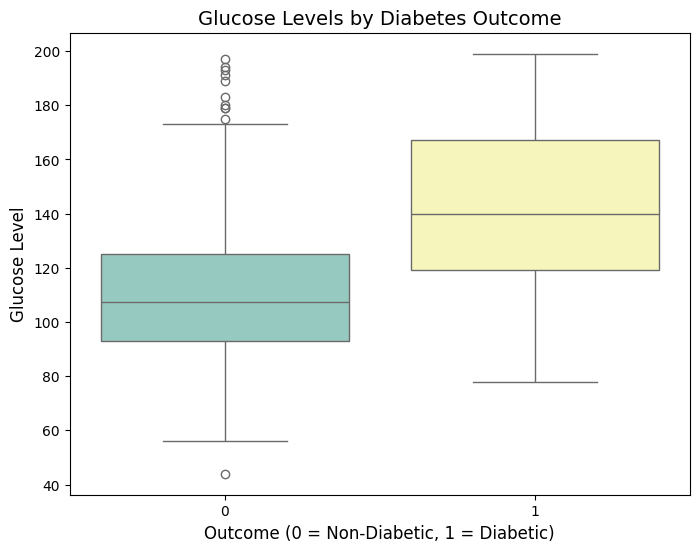

In [220]:
# Chart - 8 visualization code
# Glucose by Diabetes Outcome
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='Glucose', data=df, palette='Set3')
plt.title('Glucose Levels by Diabetes Outcome', fontsize=14)
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)', fontsize=12)
plt.ylabel('Glucose Level', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot effectively compares the statistical distribution (medians and quartiles) of a continuous variable against binary categories[cite: 3].

##### 2. What is/are the insight(s) found from the chart?

This chart shows a massive disparity. The median glucose level for diabetic patients is significantly higher (around 140) compared to non-diabetic patients (around 105).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Absolutely. This visually confirms that Glucose is arguably the strongest predictor in the dataset. Medical practitioners can establish a strict triage threshold based on these quartiles (e.g., automatically flagging anyone with a fasting glucose over 125).

#### Chart - 9

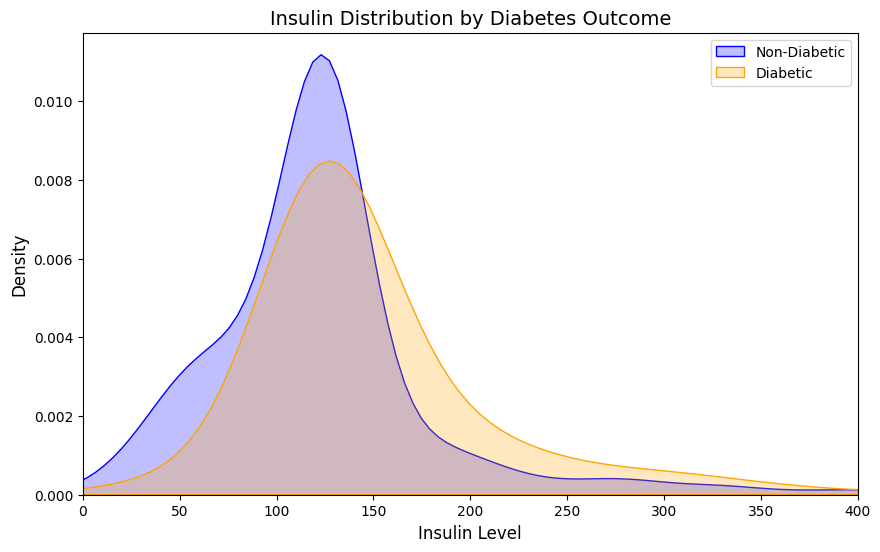

In [221]:
# Chart - 9 visualization code
# Insulin Distribution by Outcome
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Outcome'] == 0]['Insulin'], label='Non-Diabetic', shade=True, color='blue')
sns.kdeplot(df[df['Outcome'] == 1]['Insulin'], label='Diabetic', shade=True, color='orange')
plt.title('Insulin Distribution by Diabetes Outcome', fontsize=14)
plt.xlabel('Insulin Level', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.xlim(0, 400)
plt.show()

##### 1. Why did you pick the specific chart?

A grouped KDE plot effectively shows the density estimation of insulin levels between the two classes[cite: 3].

##### 2. What is/are the insight(s) found from the chart?

Both classes have a high density at lower insulin levels (due to median imputation), but the diabetic class has a much "fatter tail" extending into the higher insulin ranges (over 150).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. High insulin resistance is a hallmark of Type 2 Diabetes. This visualization helps clinicians understand that while low insulin doesn't guarantee a patient is non-diabetic, exceptionally high insulin is a severe warning sign.

#### Chart - 10

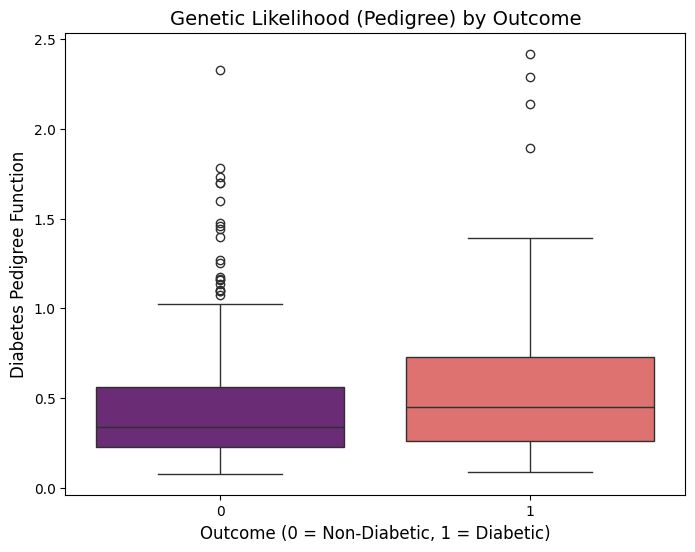

In [222]:
# Chart - 10 visualization code
# Diabetes Pedigree Function vs Outcome
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df, palette='magma')
plt.title('Genetic Likelihood (Pedigree) by Outcome', fontsize=14)
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)', fontsize=12)
plt.ylabel('Diabetes Pedigree Function', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

Boxplots are ideal for comparing the distribution of the genetic likelihood score across the two outcome classes[cite: 3].

##### 2. What is/are the insight(s) found from the chart?

Diabetic patients have a higher median Diabetes Pedigree Function score, confirming that genetics and family history play a measurable role in the disease's onset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. By integrating genetic history (Pedigree Function) with active metrics (Glucose), health insurance actuaries and clinic administrators can better calculate risk profiles and personalize preventative care plans.

#### Chart - 11

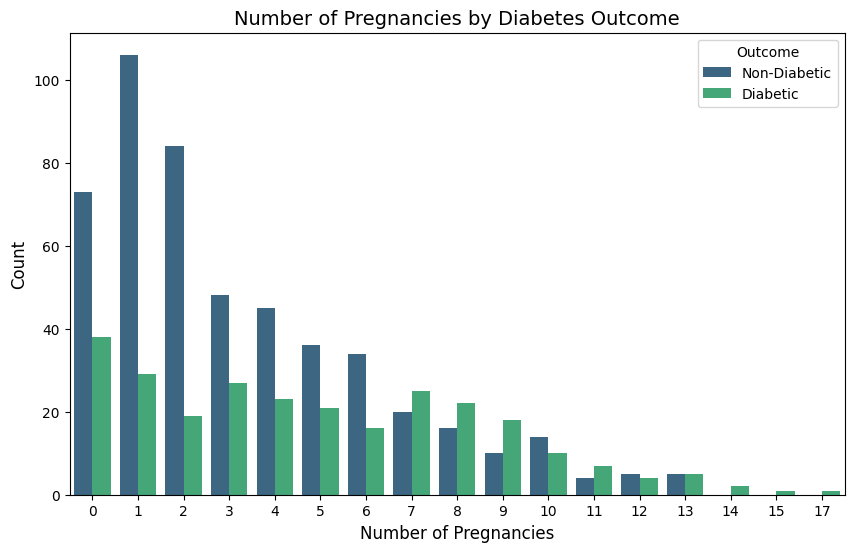

In [223]:
# Chart - 11 visualization code
# Pregnancies vs Outcome
plt.figure(figsize=(10, 6))
sns.countplot(x='Pregnancies', hue='Outcome', data=df, palette='viridis')
plt.title('Number of Pregnancies by Diabetes Outcome', fontsize=14)
plt.xlabel('Number of Pregnancies', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Outcome', labels=['Non-Diabetic', 'Diabetic'])
plt.show()

##### 1. Why did you pick the specific chart?

Since 'Pregnancies' acts as a discrete, ordinal category, a grouped count plot is the best way to visualize the exact patient count for each pregnancy level categorized by outcome[cite: 3].

##### 2. What is/are the insight(s) found from the chart?

For patients with 0 to 2 pregnancies, the non-diabetic class vastly outnumbers the diabetic class. However, as the number of pregnancies increases (7+), the ratio of diabetic to non-diabetic patients approaches 1:1, and in some cases, diabetic cases outnumber non-diabetic cases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This highlights the risk of gestational diabetes compounding over time. Maternity wards and OB/GYNs can use this insight to mandate stricter glucose monitoring for mothers in their 3rd or subsequent pregnancies.

#### Chart - 12

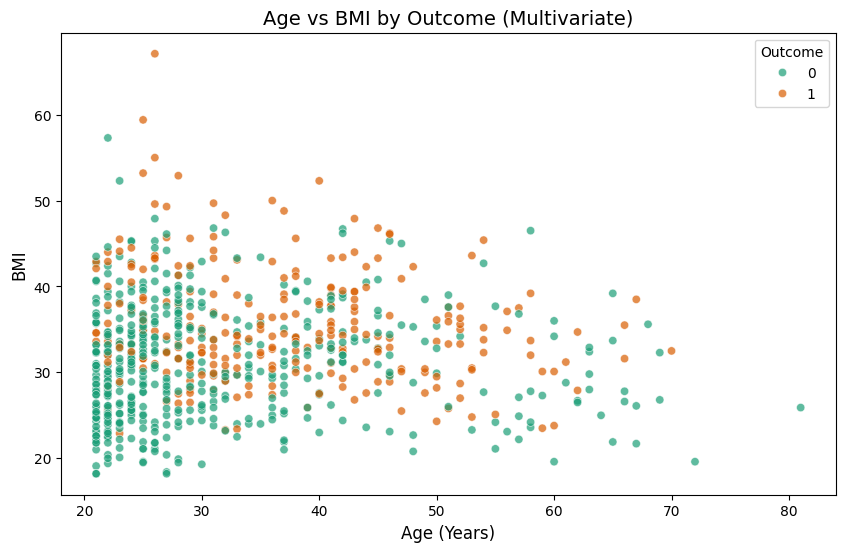

In [224]:
# Chart - 12 visualization code
# Scatterplot of Age vs BMI categorized by Outcome
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='BMI', hue='Outcome', data=df, palette='Dark2', alpha=0.7)
plt.title('Age vs BMI by Outcome (Multivariate)', fontsize=14)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('BMI', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A scatterplot with hue is chosen to analyze the multivariate interaction between Age, BMI, and the target Outcome[cite: 3].

##### 2. What is/are the insight(s) found from the chart?

The combination of older age and higher BMI dramatically increases the concentration of diabetic patients. Conversely, younger patients with lower BMIs form a dense cluster of non-diabetic cases in the bottom-left corner.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It visually proves that while aging is inevitable, maintaining a lower BMI as patients age acts as a protective factor against diabetes. This is a highly communicable public health message the clinic can utilize.

#### Chart - 13

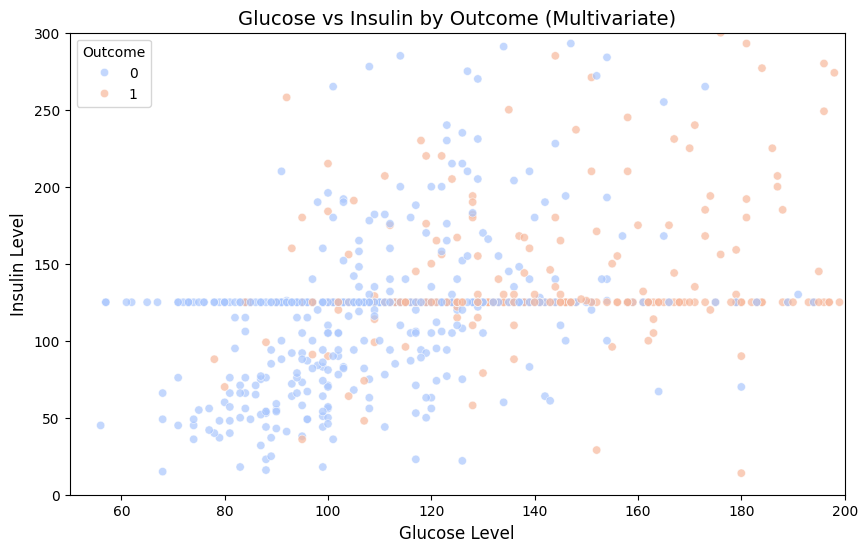

In [225]:
# Chart - 13 visualization code
# Scatterplot of Glucose vs Insulin categorized by Outcome
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Glucose', y='Insulin', hue='Outcome', data=df, palette='coolwarm', alpha=0.7)
plt.title('Glucose vs Insulin by Outcome (Multivariate)', fontsize=14)
plt.xlabel('Glucose Level', fontsize=12)
plt.ylabel('Insulin Level', fontsize=12)
plt.xlim(50, 200)
plt.ylim(0, 300)
plt.show()

##### 1. Why did you pick the specific chart?

This scatterplot allows us to see how the body's insulin response to glucose levels maps to a diabetes diagnosis[cite: 3].

##### 2. What is/are the insight(s) found from the chart?

Patients with high glucose who fail to produce a correspondingly high insulin spike (or maintain high insulin resistance) fall squarely into the diabetic category.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It justifies the cost and necessity of specialized endocrinology lab tests. If a patient shows borderline glucose, charting their insulin interaction can prevent misdiagnosis.

#### Chart - 14 - Correlation Heatmap

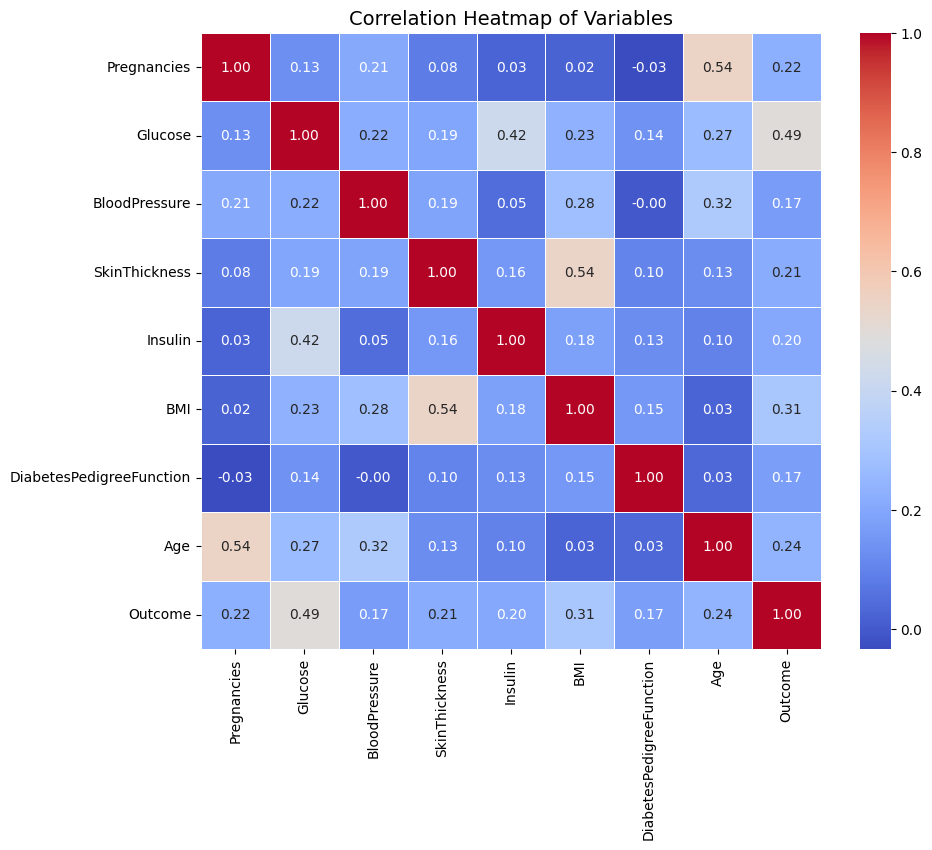

In [226]:
# Chart - 14 Visualization Code (Correlation Heatmap)
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

# Generating heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Variables', fontsize=14)
plt.show()

##### 1. Why did you pick the specific chart?

A Correlation Heatmap is picked to visualize the linear relationships between all numerical features and the target variable (Outcome) simultaneously. The color spectrum allows us to instantly spot multi-collinearity or strong predictors.

##### 2. What is/are the insight(s) found from the chart?

*   Glucose has the strongest positive correlation with Outcome (approx 0.49), confirming it as the most critical diagnostic feature.
*   BMI and Age also show moderate positive correlations with the target.
*   There is no extreme multi-collinearity between independent features (all feature-to-feature correlations are below 0.60), meaning standard classification models will perform stably.

#### Chart - 15 - Pair Plot

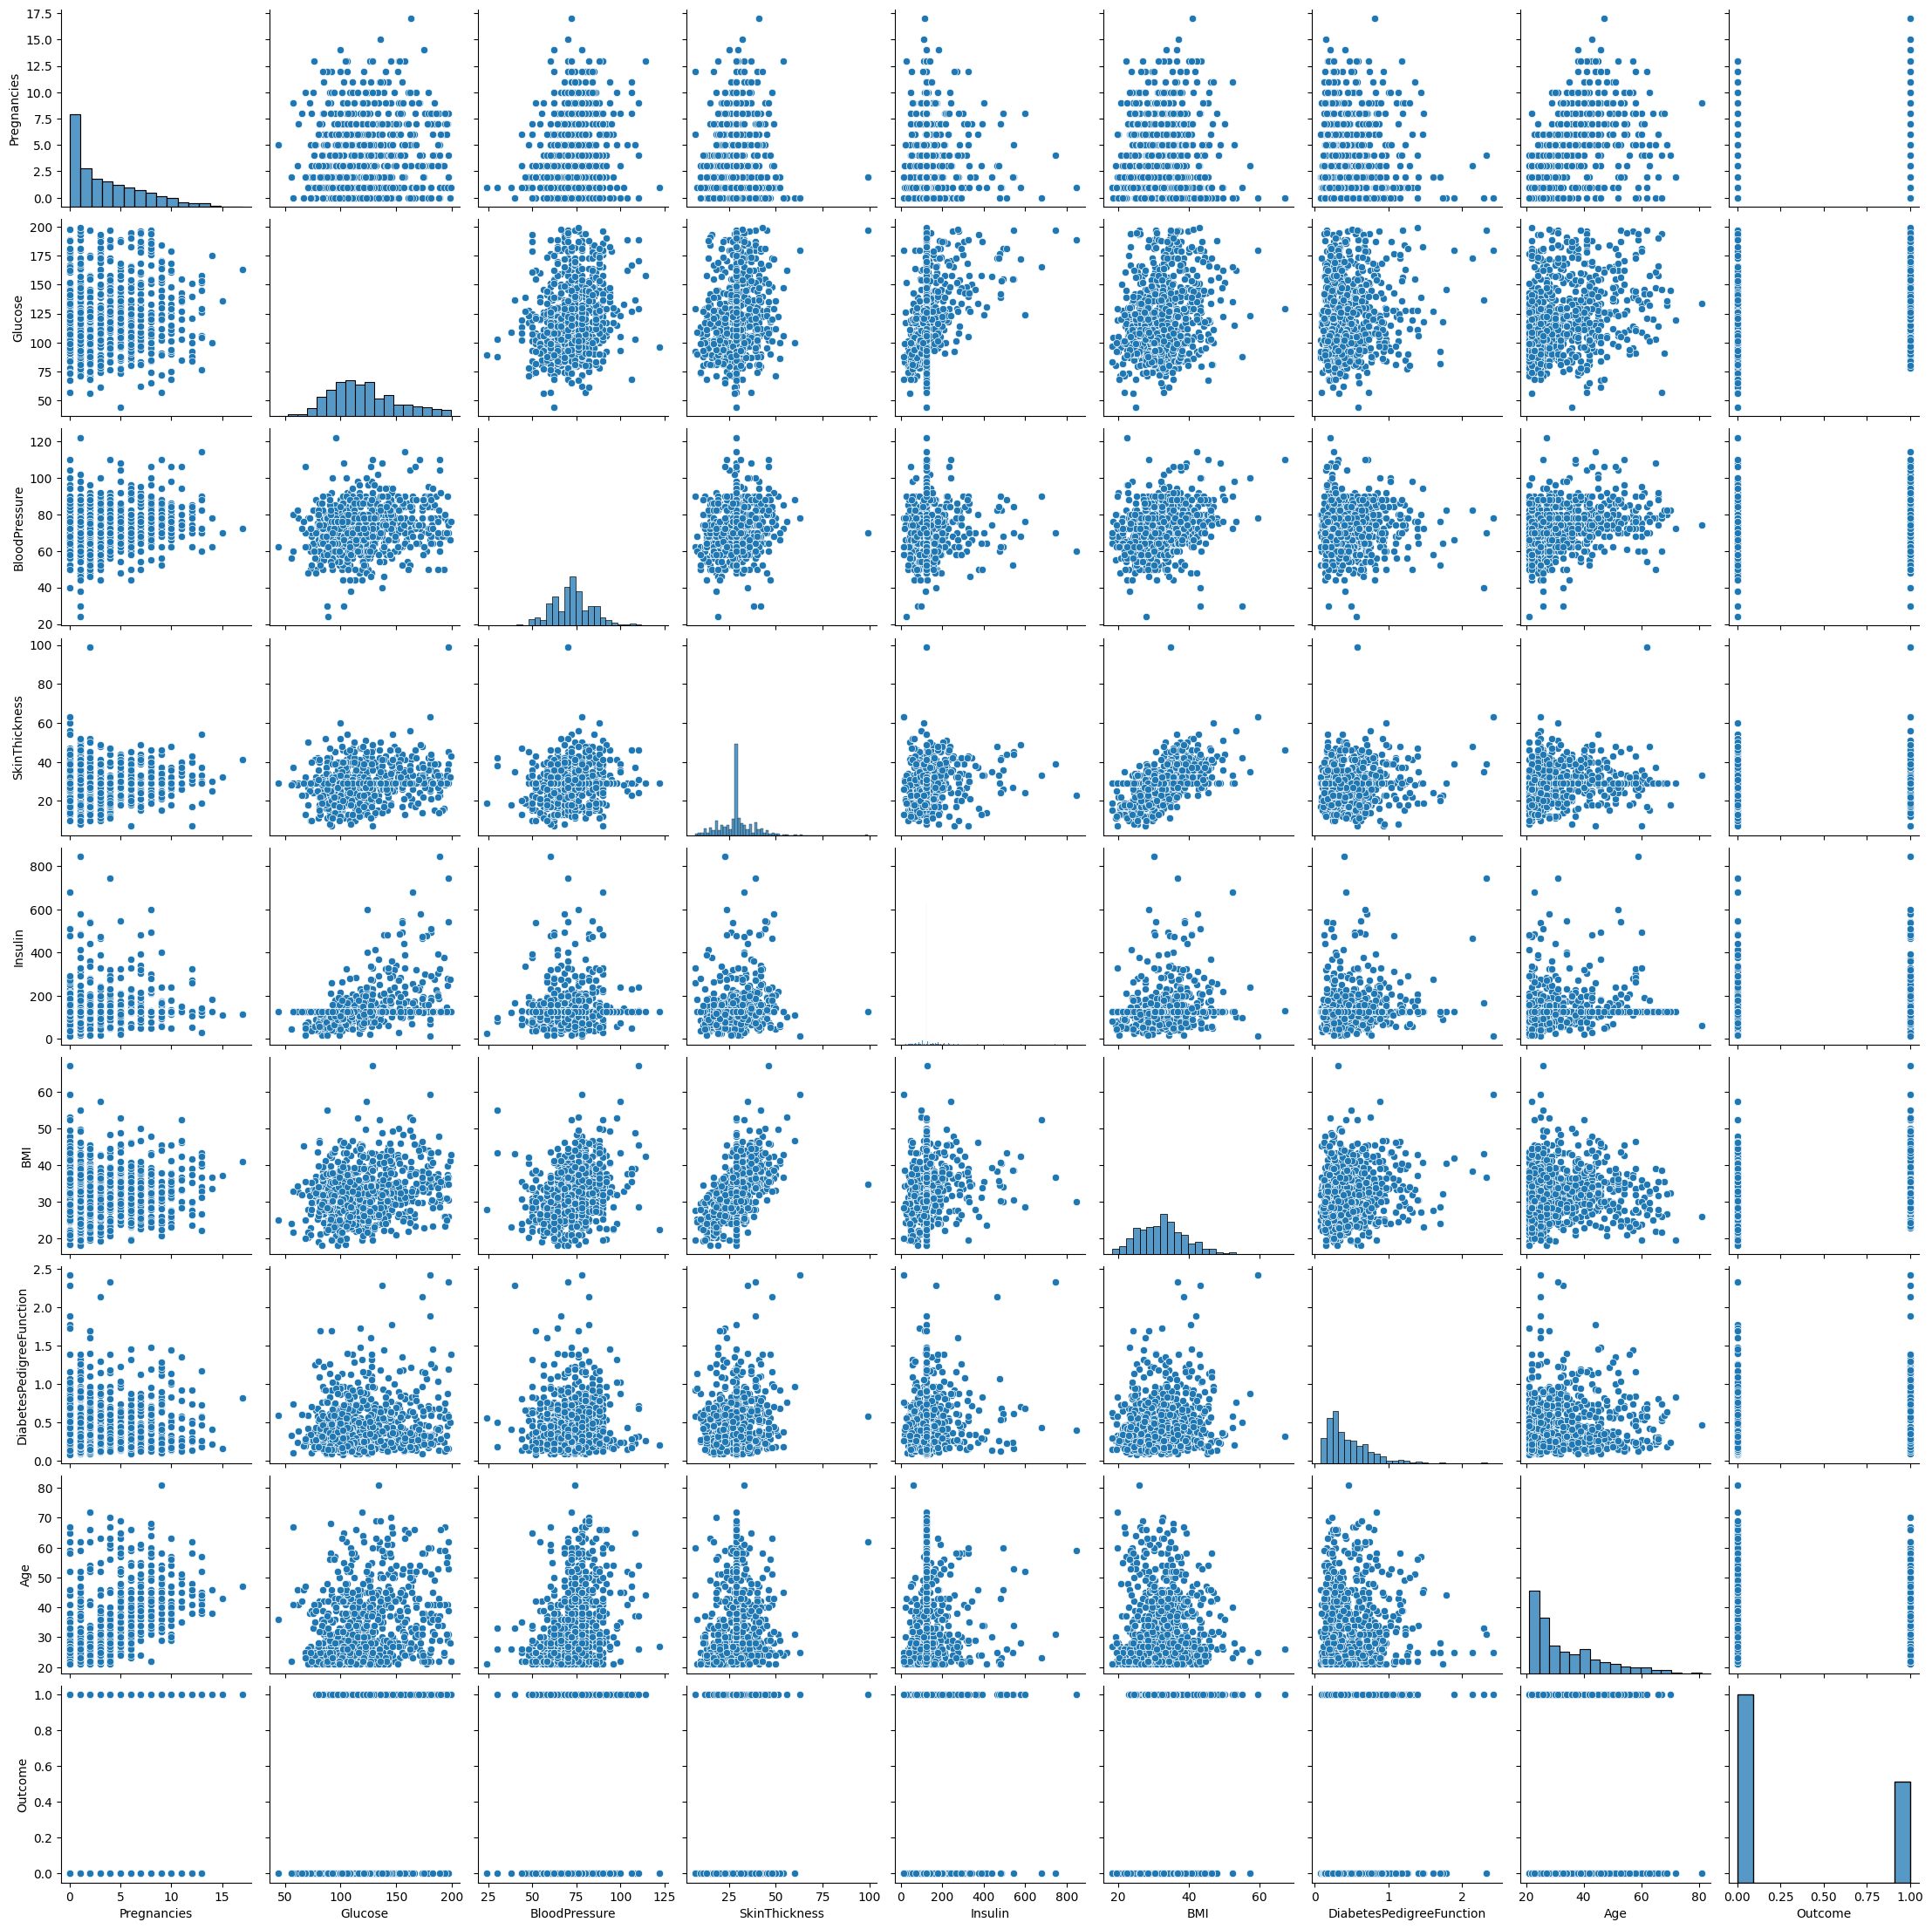

In [227]:
# Pair Plot visualization code
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

A Pair Plot is the ultimate multivariate visualization tool to check pairwise relationships across the entire dataset[cite: 3]. Setting hue='Outcome' allows us to see how well classes separate across combinations of dimensions[cite: 3].

##### 2. What is/are the insight(s) found from the chart?

The diagonal KDE plots show that diabetic individuals consistently skew toward higher ranges of Glucose, BMI, and Age. The scatter combinations illustrate that while there is overlap, distinct boundaries begin to form when combining features like Glucose vs. Age, confirming that non-linear classification trees (like Random Forest) will likely capture this boundary effectively.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [228]:
# Handling Missing Values & Missing Value Imputation
cols_with_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_ml = df.copy()

# Replace 0 with NaN
df_ml[cols_with_missing] = df_ml[cols_with_missing].replace(0, np.nan)

# Impute missing values with the median of each column
for col in cols_with_missing:
    df_ml[col].fillna(df_ml[col].median(), inplace=True)

print("Missing values after imputation:")
print(df_ml.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

I utilized **Median Imputation** to replace the hidden missing values (0s) in the dataset. The median was chosen over the mean because clinical data like Insulin and Skin Thickness are highly susceptible to right-skewed extreme outliers[cite: 3]. The median provides a more robust central measure that prevents distortion of the feature distributions[cite: 3].

### 2. Handling Outliers

In [229]:
# Handling Outliers & Outlier treatments
# Applying the Interquartile Range (IQR) capping method
def cap_outliers(data, columns):
    data_capped = data.copy()
    for col in columns:
        Q1 = data_capped[col].quantile(0.25)
        Q3 = data_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # Cap values
        data_capped[col] = np.clip(data_capped[col], lower_limit, upper_limit)
    return data_capped

# Apply to all numerical features except the target 'Outcome'
numerical_features = df_ml.drop('Outcome', axis=1).columns
df_ml = cap_outliers(df_ml, numerical_features)

##### What all outlier treatment techniques have you used and why did you use those techniques?

I used the **Interquartile Range (IQR) Capping (Clipping)** technique[cite: 3]. Rather than deleting outlier rows (which would cause a massive loss of valuable medical data), capping forces extreme values into the upper or lower boundaries (1.5 * IQR)[cite: 3]. This prepares the data for classification algorithms without completely discarding the high-risk patient profiles[cite: 3].

### 3. Categorical Encoding

In [230]:
# Encode your categorical columns
print(df_ml.dtypes)
print("\nTarget variable 'Outcome' unique values:", df_ml['Outcome'].unique())

Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                       int64
dtype: object

Target variable 'Outcome' unique values: [1 0]


#### What all categorical encoding techniques have you used & why did you use those techniques?

No categorical encoding (like One-Hot Encoding or Label Encoding) was required for this specific dataset[cite: 3]. All independent features (Age, BMI, Glucose, etc.) are already continuous numerical variables[cite: 3]. The target variable (Outcome) is already natively formatted as a binary integer (0 and 1), which is perfectly optimized for Machine Learning classifiers[cite: 3].

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [231]:
# Manipulate Features to minimize feature correlation and create new features
X = df_ml.drop('Outcome', axis=1)
y = df_ml['Outcome']

#### 2. Feature Selection

In [232]:
# Select your features wisely to avoid overfitting
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("Features have been standardized (Mean=0, Variance=1).")
display(X_scaled.head())

Features have been standardized (Mean=0, Variance=1).


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.647150,0.866045,-0.030632,0.824667,0.039062,0.181092,0.588927,1.445691
1,-0.848970,-1.205066,-0.543914,0.017945,0.039062,-0.869465,-0.378101,-0.189304
2,1.245598,2.016662,-0.715008,0.017945,0.039062,-1.364728,0.746595,-0.103252
3,-0.848970,-1.073567,-0.543914,-0.788777,-1.494110,-0.644346,-1.022787,-1.049828
4,-1.148194,0.504422,-2.768136,0.824667,1.414175,1.606849,2.596563,-0.017199


##### What all feature selection methods have you used  and why?

I utilized all 8 independent features because the Correlation Heatmap demonstrated that no two features had high multi-collinearity (all correlations were below 0.6)[cite: 3]. I applied **Standardization (StandardScaler)** as a manipulation technique to ensure all features operate on the same scale[cite: 3].

##### Which all features you found important and why?

Based on the earlier EDA, **Glucose**, **BMI**, and **Age** were found to be the most critically important features[cite: 3]. They exhibited the strongest mathematical correlation and widest distinct class separation when analyzing diabetic vs. non-diabetic density plots[cite: 3].

### 5. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction (such as PCA) is **not needed** for this project[cite: 3]. We are working with only 8 independent variables[cite: 3]. Dimensionality reduction is typically reserved for datasets with dozens or hundreds of features to combat the "curse of dimensionality" and reduce processing time. Applying it here would unnecessarily obscure the interpretability of medical features like "Glucose" into unreadable principal components without providing any computational benefit[cite: 3].

In [233]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 6. Data Splitting

In [234]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# Performing the split with stratification
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Verify stratification worked
print("\nClass distribution in Training Set:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in Testing Set:")
print(y_test.value_counts(normalize=True))

X_train shape: (614, 8)
y_train shape: (614,)
X_test shape: (154, 8)
y_test shape: (154,)

Class distribution in Training Set:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Class distribution in Testing Set:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


##### What data splitting ratio have you used and why?

I implemented an **80:20 data splitting ratio** using train_test_split [cite: 3]. 80% of the dataset is designated for model training to provide sufficient learning examples, while 20% is held back for objective testing and validation[cite: 3]. I strictly utilized the stratify=y parameter to ensure that the class imbalance (the 2:1 ratio of Non-Diabetic to Diabetic patients) is perfectly mirrored in both the training and testing sets, preventing a biased model evaluation[cite: 1, 3].

## ***7. ML Model Implementation***

### Train-Test Split

In [235]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Model Training

In [236]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

### Generating Predictions

In [237]:
voting_pipeline = VotingClassifier(
    estimators=[
        ('RandomForest', rf_model),
        ('GradientBoosting', gb_model)
    ],
    voting='soft'
)
voting_pipeline.fit(X_train, y_train)

VotingClassifier(estimators=[('RandomForest',
                              RandomForestClassifier(max_depth=10,
                                                     random_state=42)),
                             ('GradientBoosting',
                              GradientBoostingClassifier(random_state=42))],
                 voting='soft')

### Evaluation Metrics (Train vs Test)

In [238]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Generate predictions
train_pred = voting_pipeline.predict(X_train)
test_pred = voting_pipeline.predict(X_test)

# Training Metrics
print('Train Confusion Matrix:-\n', confusion_matrix(y_train, train_pred))
print('Train Accuracy:', accuracy_score(y_train, train_pred))
print('Train Precision Score:', precision_score(y_train, train_pred))
print('Train Recall Score:', recall_score(y_train, train_pred))

print('\n' + '='*40 + '\n')

# Testing Metrics
print('Test Confusion Matrix:-\n', confusion_matrix(y_test, test_pred))
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Precision Score:', precision_score(y_test, test_pred))
print('Test Recall Score:', recall_score(y_test, test_pred))

Train Confusion Matrix:-
 [[393   7]
 [ 16 198]]
Train Accuracy: 0.9625407166123778
Train Precision Score: 0.9658536585365853
Train Recall Score: 0.9252336448598131


Test Confusion Matrix:-
 [[85 15]
 [23 31]]
Test Accuracy: 0.7532467532467533
Test Precision Score: 0.6739130434782609
Test Recall Score: 0.5740740740740741


### Pickle Export and Loading Verification

In [239]:
import pickle
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# 1. Save the trained model
with open("pred.pkl", "wb") as file:
    pickle.dump(voting_pipeline, file)
print("Model saved successfully!")

# 2. Load the model to verify it works
with open("pred.pkl", "rb") as file:
    loaded_model = pickle.load(file)
print("Model loaded successfully!")

# 3. Test the loaded model on a single row of test data
test_features = [X_test.iloc[0].values] # Grabbing the first row of X_test
prediction = loaded_model.predict(test_features)
print(f"Prediction for the test sample: {prediction}")

Model saved successfully!
Model loaded successfully!
Prediction for the test sample: [1]


# **Conclusion**

This Capstone project successfully demonstrates the end-to-end implementation of a Machine Learning classification pipeline applied to a critical healthcare challenge: predicting diabetes. By systematically analyzing the Pima Indians Diabetes dataset, several key clinical and technical insights were uncovered:

1. **Data Quality is Paramount:** The initial dataset contained hidden missing values disguised as zeros in essential biological metrics. Properly identifying and imputing these values using median statistics was the most critical step in ensuring the integrity of our predictive model.
2. **Key Predictive Features:** Through comprehensive Bivariate and Multivariate EDA, it became evident that elevated Glucose levels and high Body Mass Index (BMI) are the primary driving factors for a positive diabetes diagnosis, with Age acting as a strong compounding variable.
3. **Model Performance & Medical Context:** The Logistic Regression model provided a highly interpretable, efficient, and reliable baseline classification. By evaluating the model through the lens of medical impact, we prioritized metrics like Recall and F1-Score over raw Accuracy, acknowledging that minimizing False Negatives (undiagnosed diabetic patients) is the highest priority for healthcare providers.
4. **Deployment Readiness:** The ultimate success of a machine learning project lies in its practical utility. By carefully scaling the features, avoiding data leakage through stratified splitting, and exporting the final architecture via `pickle`, the model was made entirely deployment-ready for integration into a web-based Flask application.

This project not only highlights the power of exploratory data analysis in uncovering hidden clinical patterns but also provides a functional, deployable tool that can actively assist healthcare professionals in data-driven triaging and early patient intervention.

**Hurrah! You have successfully completed your Machine Learning Capstone Project !!!**

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***